# 📰 BBC News Classification using Machine Learning

Objective:
Build an end-to-end Natural Language Processing (NLP) pipeline to classify BBC news articles into different categories using machine learning algorithms.

**Tech Stack:**
Python, Pandas, NumPy, Matplotlib, Scikit-learn

In [229]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [230]:
df=pd.read_csv('bbc-text.csv')
df.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


In [231]:
X=df['text']
y=df['category']


In [232]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=42)


In [233]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer=CountVectorizer()
X_train_vectors=vectorizer.fit_transform(X_train)
X_test_vectors=vectorizer.transform(X_test)

In [234]:
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression(max_iter=5000)

lr.fit(X_train_vectors,y_train)

y_pred_lr=lr.predict(X_test_vectors)

In [235]:
sentences=['England sealed their first-ever T20 series victory over India as their opponents suffered a record fifth straight defeat in completed 20-over matches. Set 159 to win, Phil Salt and captain Harry Brook put on an unbroken second-wicket partnership of 144 as England cruised to their target in 13.5 overs in the fourth T20 at Bristol. Brook powered 79 from 35 deliveries, while Salt hit 59 from 42 despite not scoring off his first nine balls. England now hold an insurmountable 3-0 lead in the five-match series, winning the past three games in fine fashion after the first fixture at Chester-le-Street was washed out. The run of defeats for India, coupled with two surprise losses to Ireland prior to this series, heaps pressure on Shreyas Iyer, who took over the India T20 captaincy in early June.']
sentences_vector=vectorizer.transform(sentence)

sentences_prediction=lr.predict(sentences_vector)

print(sentences_prediction)

['sport']


In [236]:
from sklearn.metrics import accuracy_score,classification_report

results={}

print("Accuracy score: ", accuracy_score(y_test,y_pred_lr))

print("\nClassification Report: ")
print(classification_report(y_test,y_pred_lr))

results["Logistic Regression"] = accuracy_score(y_test, y_pred_lr)


Accuracy score:  0.9591836734693877

Classification Report: 
               precision    recall  f1-score   support

     business       0.94      0.96      0.95       181
entertainment       0.97      0.93      0.95       129
     politics       0.94      0.95      0.95       125
        sport       0.97      0.99      0.98       158
         tech       0.98      0.96      0.97       142

     accuracy                           0.96       735
    macro avg       0.96      0.96      0.96       735
 weighted avg       0.96      0.96      0.96       735



In [237]:
from sklearn.naive_bayes import MultinomialNB

nb=MultinomialNB()

nb.fit(X_train_vectors,y_train)

y_pred_nb=nb.predict(X_test_vectors)

In [238]:
print("Accuracy score: ", accuracy_score(y_test,y_pred_nb))

print("\nClassification Report: ")
print(classification_report(y_test,y_pred_nb))

results["Naive Bayes"] = accuracy_score(y_test, y_pred_nb)

Accuracy score:  0.9727891156462585

Classification Report: 
               precision    recall  f1-score   support

     business       0.99      0.95      0.97       181
entertainment       1.00      0.92      0.96       129
     politics       0.92      0.99      0.95       125
        sport       1.00      1.00      1.00       158
         tech       0.95      1.00      0.98       142

     accuracy                           0.97       735
    macro avg       0.97      0.97      0.97       735
 weighted avg       0.97      0.97      0.97       735



In [239]:
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(n_estimators=500,random_state=42)
#The number of estimators was tuned by experimenting with different values, and 500 trees provided the best validation performance

rf.fit(X_train_vectors,y_train)

y_pred_rf=rf.predict(X_test_vectors)

In [240]:
print("Accuracy score: ", accuracy_score(y_test,y_pred_rf))

print("\nClassification Report: ")
print(classification_report(y_test,y_pred_rf))

results["Random Forest"] = accuracy_score(y_test, y_pred_rf)

Accuracy score:  0.9523809523809523

Classification Report: 
               precision    recall  f1-score   support

     business       0.92      0.97      0.94       181
entertainment       0.99      0.91      0.95       129
     politics       0.92      0.95      0.94       125
        sport       0.97      0.99      0.98       158
         tech       0.98      0.93      0.95       142

     accuracy                           0.95       735
    macro avg       0.96      0.95      0.95       735
 weighted avg       0.95      0.95      0.95       735



In [241]:
from sklearn.svm import SVC

svm=SVC(kernel='linear')

svm.fit(X_train_vectors,y_train)

y_pred_svm = svm.predict(X_test_vectors)

In [242]:
print("Accuracy score: ", accuracy_score(y_test,y_pred_svm))

print("\nClassification Report: ")
print(classification_report(y_test,y_pred_svm))

results["SVM"] = accuracy_score(y_test, y_pred_svm)

Accuracy score:  0.9564625850340136

Classification Report: 
               precision    recall  f1-score   support

     business       0.94      0.94      0.94       181
entertainment       0.98      0.93      0.95       129
     politics       0.93      0.94      0.94       125
        sport       0.98      0.99      0.98       158
         tech       0.96      0.96      0.96       142

     accuracy                           0.96       735
    macro avg       0.96      0.96      0.96       735
 weighted avg       0.96      0.96      0.96       735



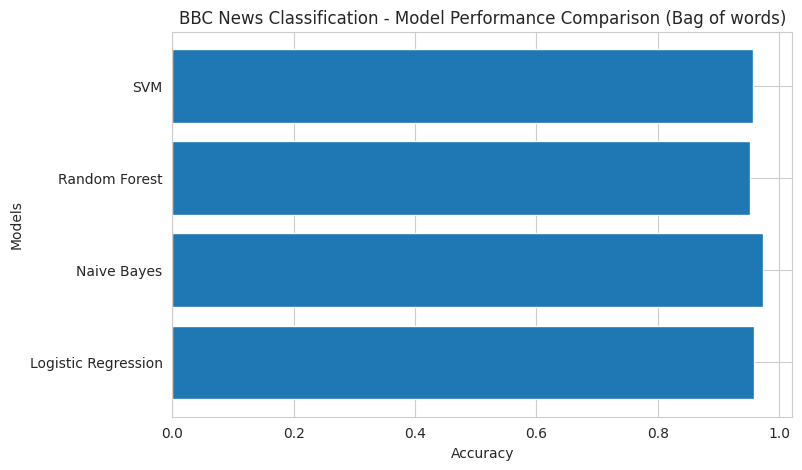

In [243]:
models = list(results.keys())
accuracy = list(results.values())

plt.figure(figsize=(8,5))
sns.set_style("whitegrid")


plt.barh(models, accuracy)

plt.xlabel("Accuracy")
plt.ylabel("Models")
plt.title("BBC News Classification - Model Performance Comparison (Bag of words)")


plt.show()

In [244]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [245]:
#Logistic Regression

lr.fit(X_train_tfidf,y_train)

y_pred_tfidf_lr=lr.predict(X_test_tfidf)

In [246]:
results_tfidf={}

print("Accuracy score: ", accuracy_score(y_test,y_pred_tfidf_lr))

print("\nClassification Report: ")
print(classification_report(y_test,y_pred_tfidf_lr))

results_tfidf["Logistic Regression"] = accuracy_score(y_test, y_pred_tfidf_lr)


Accuracy score:  0.9673469387755103

Classification Report: 
               precision    recall  f1-score   support

     business       0.94      0.97      0.95       181
entertainment       0.98      0.94      0.96       129
     politics       0.96      0.94      0.95       125
        sport       0.99      1.00      1.00       158
         tech       0.97      0.98      0.98       142

     accuracy                           0.97       735
    macro avg       0.97      0.97      0.97       735
 weighted avg       0.97      0.97      0.97       735



In [247]:
#Naive Bayes

nb.fit(X_train_tfidf,y_train)

y_pred_tfidf_nb=nb.predict(X_test_tfidf)

In [248]:
print("Accuracy score: ", accuracy_score(y_test,y_pred_tfidf_nb))

print("\nClassification Report: ")
print(classification_report(y_test,y_pred_tfidf_nb))

results_tfidf["Naive Bayes"] = accuracy_score(y_test, y_pred_tfidf_nb)


Accuracy score:  0.9360544217687075

Classification Report: 
               precision    recall  f1-score   support

     business       0.96      0.94      0.95       181
entertainment       1.00      0.81      0.89       129
     politics       0.86      0.99      0.92       125
        sport       0.90      1.00      0.95       158
         tech       0.98      0.93      0.95       142

     accuracy                           0.94       735
    macro avg       0.94      0.93      0.93       735
 weighted avg       0.94      0.94      0.94       735



In [249]:
#Random Forest

rf.fit(X_train_tfidf,y_train)

y_pred_tfidf_rf=rf.predict(X_test_tfidf)

In [250]:
print("Accuracy score: ", accuracy_score(y_test,y_pred_tfidf_rf))

print("\nClassification Report: ")
print(classification_report(y_test,y_pred_tfidf_rf))

results_tfidf["Random Forest"] = accuracy_score(y_test, y_pred_tfidf_rf)


Accuracy score:  0.9469387755102041

Classification Report: 
               precision    recall  f1-score   support

     business       0.90      0.96      0.93       181
entertainment       0.97      0.89      0.93       129
     politics       0.94      0.94      0.94       125
        sport       0.97      0.99      0.98       158
         tech       0.97      0.93      0.95       142

     accuracy                           0.95       735
    macro avg       0.95      0.94      0.95       735
 weighted avg       0.95      0.95      0.95       735



In [251]:
#SVM

svm.fit(X_train_tfidf,y_train)

y_pred_tfidf_svm=svm.predict(X_test_tfidf)


In [252]:
print("Accuracy score: ", accuracy_score(y_test,y_pred_tfidf_svm))

print("\nClassification Report: ")
print(classification_report(y_test,y_pred_tfidf_svm))

results_tfidf["SVM"] = accuracy_score(y_test, y_pred_tfidf_svm)


Accuracy score:  0.9755102040816327

Classification Report: 
               precision    recall  f1-score   support

     business       0.97      0.96      0.96       181
entertainment       0.98      0.96      0.97       129
     politics       0.95      0.96      0.96       125
        sport       0.99      1.00      1.00       158
         tech       0.98      0.99      0.99       142

     accuracy                           0.98       735
    macro avg       0.98      0.98      0.98       735
 weighted avg       0.98      0.98      0.98       735



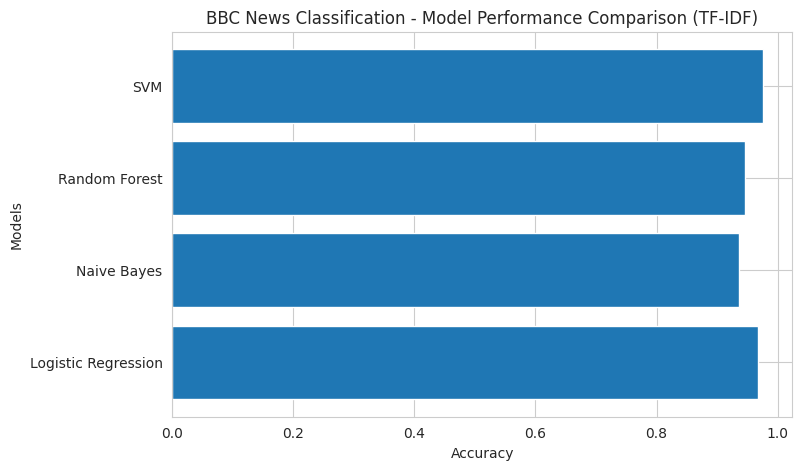

In [253]:
models = list(results_tfidf.keys())
accuracy = list(results_tfidf.values())

plt.figure(figsize=(8,5))
sns.set_style("whitegrid")


plt.barh(models, accuracy)

plt.xlabel("Accuracy")
plt.ylabel("Models")
plt.title("BBC News Classification - Model Performance Comparison (TF-IDF)")


plt.show()

In [254]:
new_results = []

for model, accuracy in results.items():
    new_results.append({
        "Model": model,
        "Accuracy": accuracy,
        "Vectorization": "Bag of Words"
    })

for model, accuracy in results_tfidf.items():
    new_results.append({
        "Model": model,
        "Accuracy": accuracy,
        "Vectorization": "TF-IDF"
    })

df_results = pd.DataFrame(new_results)

df_results

,Model,Accuracy,Vectorization
0,Logistic Regression,0.959184,Bag of Words
1,Naive Bayes,0.972789,Bag of Words
2,Random Forest,0.952381,Bag of Words
3,SVM,0.956463,Bag of Words
4,Logistic Regression,0.967347,TF-IDF
5,Naive Bayes,0.936054,TF-IDF
6,Random Forest,0.946939,TF-IDF
7,SVM,0.975510,TF-IDF


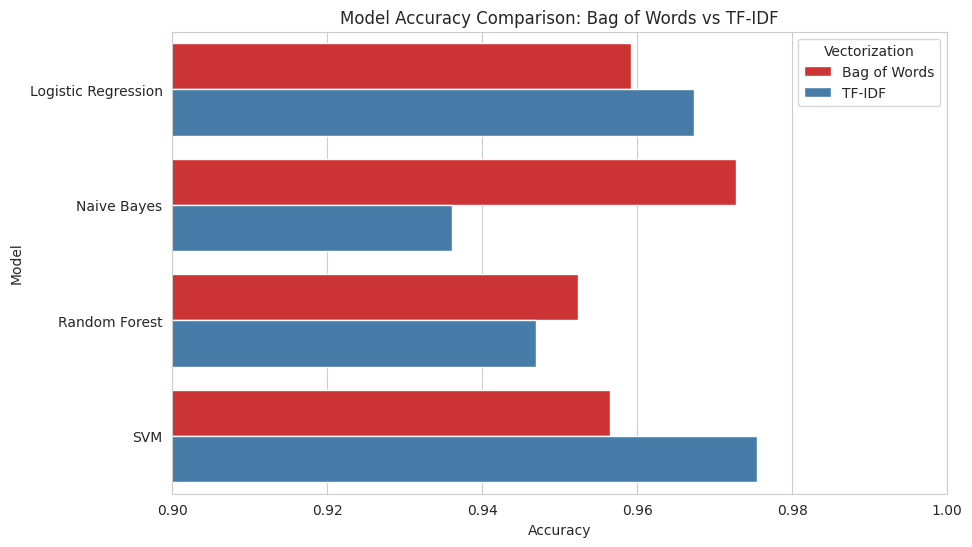

In [255]:
plt.figure(figsize=(10,6))

sns.set_style("whitegrid")

sns.barplot(
    data=df_results,
    x="Accuracy",
    y="Model",
    hue="Vectorization",
    palette="Set1"
)

plt.title("Model Accuracy Comparison: Bag of Words vs TF-IDF")
plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.xlim(0.9, 1.0)

plt.show()